In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import torchvision.transforms.v2 as v2
from torchvision.models import resnet50
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid

from torch.utils.data.dataloader import DataLoader
from sklearn.utils import shuffle
from tqdm import tqdm

from sklearn.metrics import roc_auc_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [2]:
TRAIN_PATH = "data/train"
VAL_PATH   = "data/val"
TEST_PATH  = "data/test"

SIZE = 224
BATCH_SIZE = 64
EPOCHS = 1
PATIENCE = 5
LR = 1e-5

In [3]:
def show_all_images_counts(all_path):
    all_images_counts = {}

    for path in all_path:
        if not os.path.exists(path):
            print("Missing:", path)
            continue

        img_counts = {}
        for label in os.listdir(path):
            label_path = os.path.join(path, label)

            if os.path.isdir(label_path):
                img_counts[label] = len(os.listdir(label_path))

        all_images_counts[os.path.basename(path)] = img_counts

    return all_images_counts


all_counts = show_all_images_counts([TRAIN_PATH, VAL_PATH, TEST_PATH])

print(all_counts["train"])
print(all_counts["val"])
print(all_counts["test"])

{'sleepy': 25167, 'awake': 25770}
{'sleepy': 8389, 'awake': 8591}
{'sleepy': 8390, 'awake': 8591}


In [4]:
print(f'All Images Counts In Train: {all_counts["train"]}\n')
print(f'All Images Counts In Val: {all_counts["val"]}\n')
print(f'All Images Counts In Test: {all_counts["test"]}\n')

All Images Counts In Train: {'sleepy': 25167, 'awake': 25770}

All Images Counts In Val: {'sleepy': 8389, 'awake': 8591}

All Images Counts In Test: {'sleepy': 8390, 'awake': 8591}



In [5]:
import os
import matplotlib.pyplot as plt

def show_all_sizes(all_path: list):
    """Collect unique image dimensions across each split."""
    all_sizes = {}

    for path in all_path:
        if not os.path.exists(path):
            print(f"Path not found: {path}")
            continue

        sizes = []

        for label_name in os.listdir(path):
            label_path = os.path.join(path, label_name)

            if not os.path.isdir(label_path):
                continue

            for img in os.listdir(label_path):
                img_path = os.path.join(label_path, img)

                try:
                    img_array = plt.imread(img_path)
                    sizes.append(img_array.shape)
                except Exception:
                    continue

        # ✅ FIX: cross-platform safe key
        split_name = os.path.basename(path)
        all_sizes[split_name] = set(sizes)

    return all_sizes


all_sizes = show_all_sizes([TRAIN_PATH, VAL_PATH, TEST_PATH])

In [6]:
print(f"Train sizes: {all_sizes['train']}\nCount: {len(all_sizes['train'])}\n")
print(f"Val sizes: {all_sizes['val']}\nCount: {len(all_sizes['val'])}\n")
print(f"Test sizes: {all_sizes['test']}\nCount: {len(all_sizes['test'])}\n")

Train sizes: {(267, 267), (84, 84), (277, 277), (116, 116), (61, 61), (126, 126), (181, 181), (272, 272), (176, 176), (153, 153), (208, 208), (218, 218), (57, 57), (122, 122), (117, 117), (94, 94), (149, 149), (214, 214), (209, 209), (241, 241), (58, 58), (90, 90), (246, 246), (150, 150), (127, 127), (182, 182), (242, 242), (297, 297), (274, 274), (91, 91), (68, 68), (123, 123), (63, 63), (238, 238), (183, 183), (160, 160), (215, 215), (64, 64), (220, 220), (59, 59), (124, 124), (101, 101), (156, 156), (216, 216), (248, 248), (65, 65), (97, 97), (253, 253), (92, 92), (157, 157), (212, 212), (189, 189), (184, 184), (194, 194), (88, 88), (98, 98), (286, 286), (125, 125), (70, 70), (180, 180), (190, 190), (245, 245), (222, 222), (217, 217), (282, 282), (66, 66), (121, 121), (227, 227), (131, 131), (186, 186), (158, 158), (213, 213), (223, 223), (62, 62), (278, 278), (72, 72), (250, 250), (260, 260), (99, 99), (154, 154), (164, 164), (219, 219), (159, 159), (191, 191), (256, 256), (95, 95)

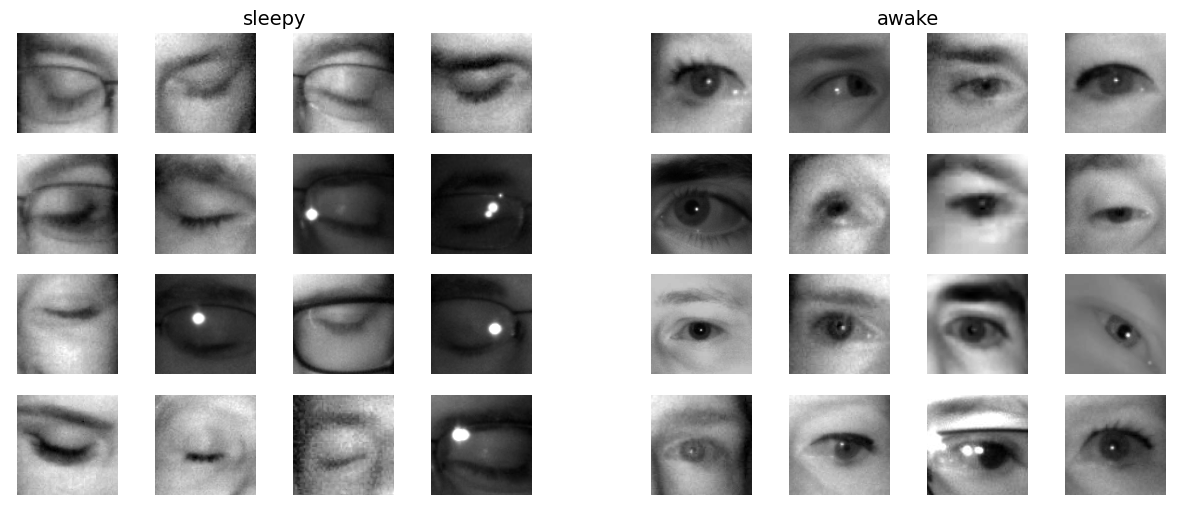

In [7]:
def show_random_image(PATH, num_of_samples=16):
    """Display a 4x4 grid of random samples per class side by side."""
    labels = os.listdir(PATH)
    fig = plt.figure(figsize=(15, 6))
    outer = fig.add_gridspec(1, 2, wspace=0.2)

    for j, label_name in enumerate(labels[:2]):
        label_path = os.path.join(PATH, label_name)
        images = shuffle(os.listdir(label_path))[:num_of_samples]
        inner = outer[j].subgridspec(4, 4)

        ax_title = fig.add_subplot(outer[j])
        ax_title.set_title(label_name, fontsize=14)
        ax_title.axis("off")

        for i, img_name in enumerate(images):
            r, c = divmod(i, 4)
            ax = fig.add_subplot(inner[r, c])
            ax.imshow(plt.imread(os.path.join(label_path, img_name)), cmap="gray")
            ax.axis("off")

    plt.show()

show_random_image(TRAIN_PATH)


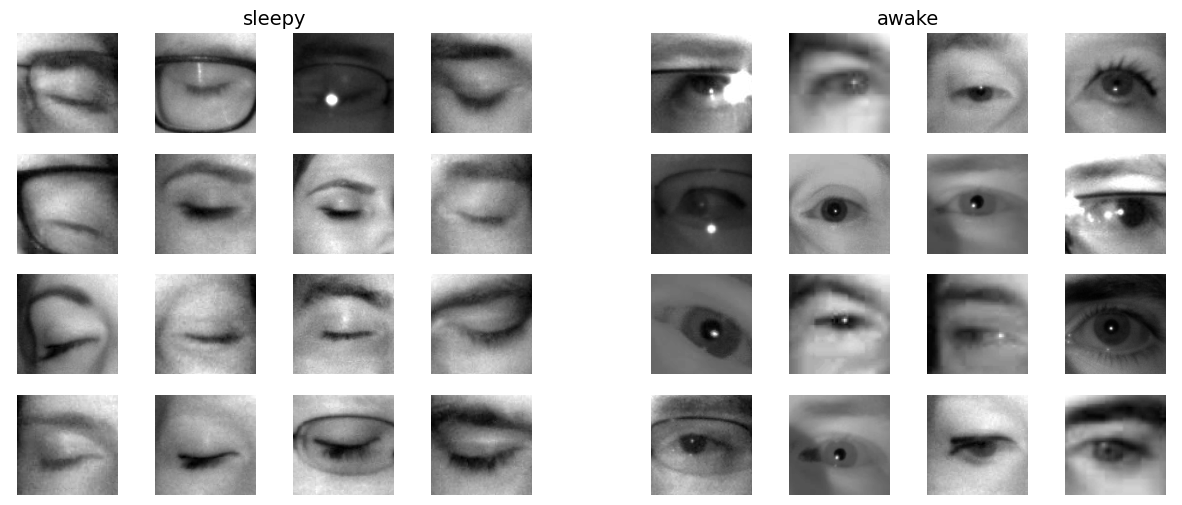

In [8]:
show_random_image(VAL_PATH)

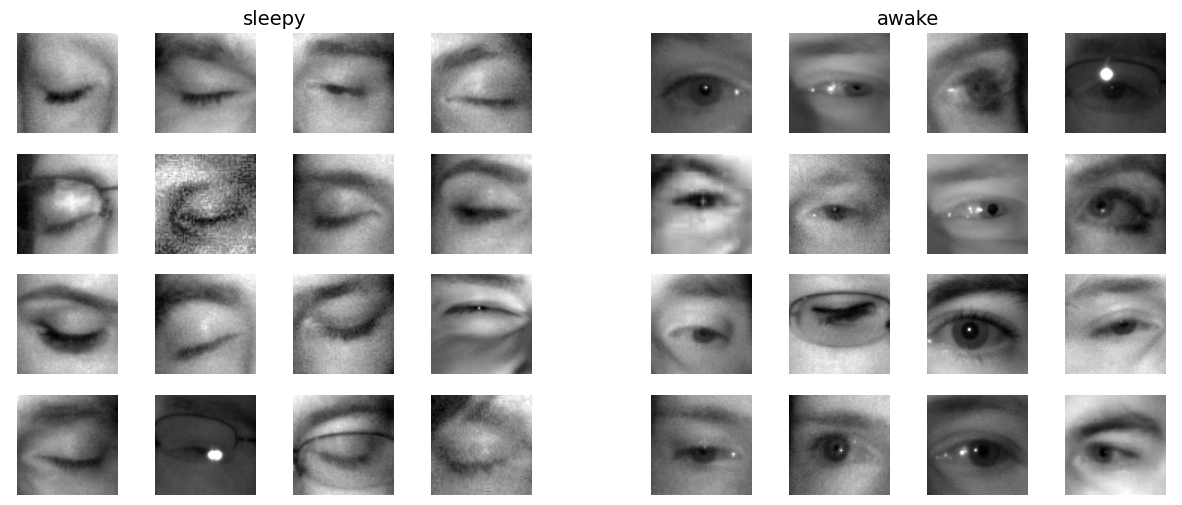

In [9]:
show_random_image(TEST_PATH)

In [10]:
def get_transforms(train=False):
    base = [
        v2.Resize((SIZE, SIZE)),
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
    ]

    aug = [
        v2.RandomHorizontalFlip(),
        v2.RandomRotation(20),
    ]

    # ✅ FIX: 3-channel for ResNet
    tail = [
        v2.Grayscale(num_output_channels=3),
    ]

    if train:
        return v2.Compose(base + aug + tail)
    return v2.Compose(base + tail)


In [20]:
def prepare_dataloader(train_p, val_p, test_p, img_size=SIZE, batch_size=BATCH_SIZE):
    """Load datasets and wrap them in DataLoaders."""
    train_ds = ImageFolder(TRAIN_PATH, transform=get_transforms(train=True))
    val_ds   = ImageFolder(VAL_PATH, transform=get_transforms())
    test_ds  = ImageFolder(TEST_PATH, transform=get_transforms())

    print(len(train_ds), len(val_ds), len(test_ds))

    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_dl   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    test_dl  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

    print("Data loaded successfully.")
    return train_dl, val_dl, test_dl


In [21]:
train_dl,val_dl,test_dl = prepare_dataloader(TRAIN_PATH,VAL_PATH,TEST_PATH)

50937 16980 16981
Data loaded successfully.


In [22]:
imgs , _ = next(iter(train))
imgs[0].shape

torch.Size([3, 224, 224])

In [23]:
def denorm(imgs):
    """Reverse normalization from [-1, 1] back to [0, 1] for display."""
    return (imgs + 1) / 2


(-0.5, 3617.5, 905.5, -0.5)

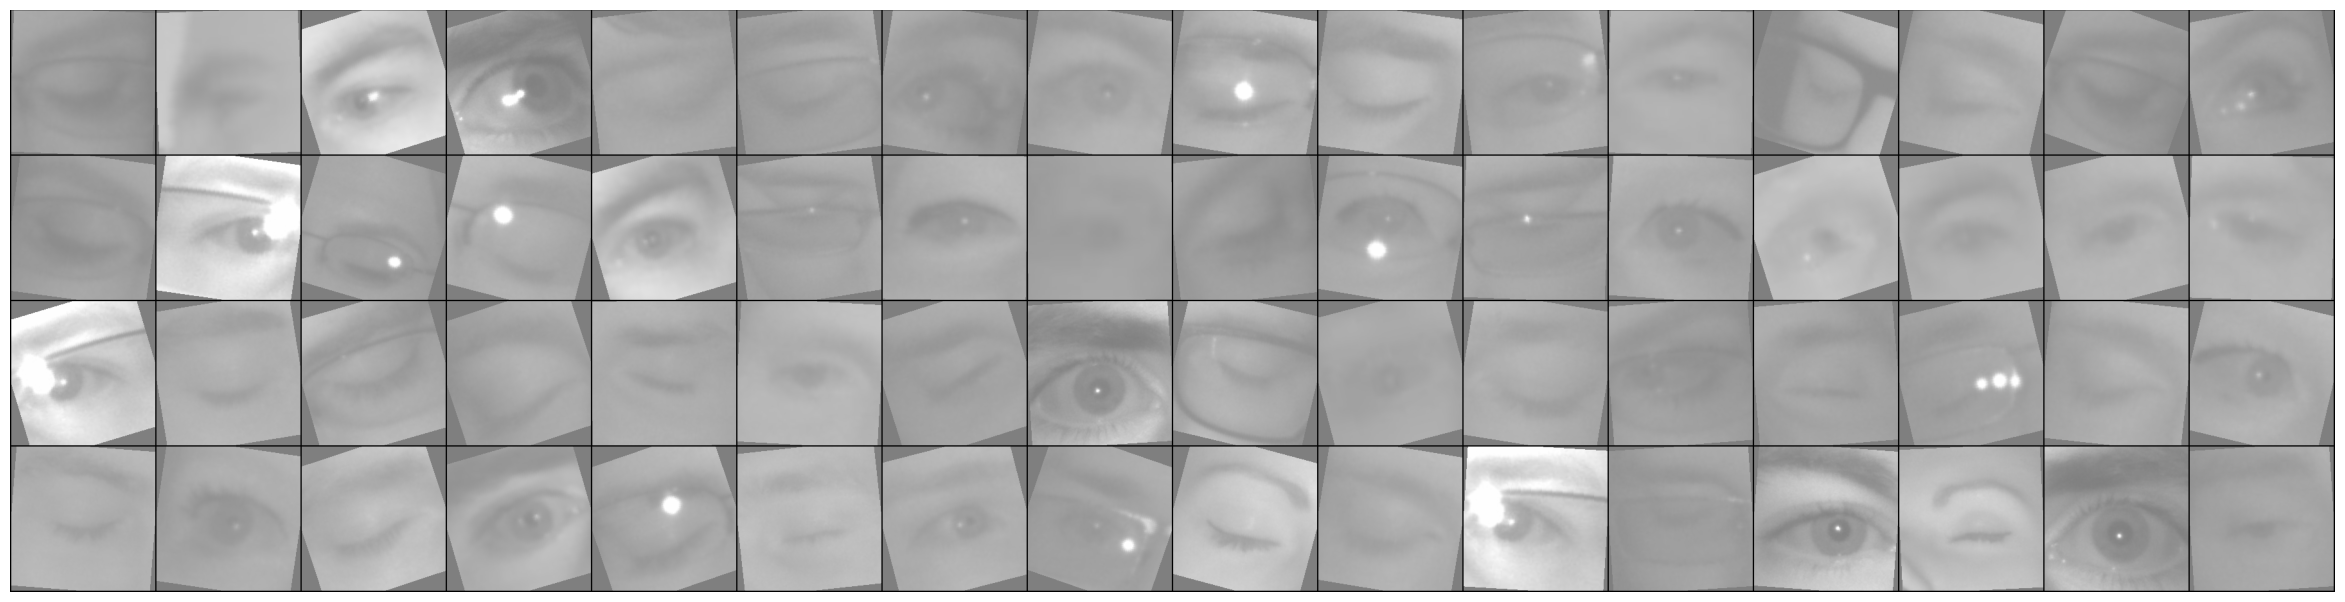

In [24]:
imgs,labels = next(iter(train))
plt.figure(figsize=(30, 30))

plt.imshow(make_grid(denorm(imgs),16).permute(1,2,0),cmap="gray")
plt.axis("off")

In [25]:
def replace_classifier(model, name):
    """
    Swap the final classification head for a 2-class output.

    Supported architectures: ResNet, InceptionV3, EfficientNet

    Parameters
    ----------
    model : pretrained PyTorch model
    name  : str — model class name (used to identify head location)
    """
    if "Inception" in name:
        model.classifier = nn.Linear(model.classifier.in_features, 2)

    elif "ResNet" in name:
        model.fc = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(model.fc.in_features, 2)
        )

    elif "EfficientNet" in name:
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)

    return model


In [26]:
def build_model():
    model = resnet50(weights="DEFAULT")

    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(model.fc.in_features, 2)
    )

    return model.to(device)

In [27]:
def fit():
    model = build_model()
    optimizer = optim.AdamW(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    best_auc = 0
    counter = 0
    history = []
    best_epoch = 0

    for epoch in range(EPOCHS):
        model.train()

        train_loss = []
        train_preds, train_labels = [], []

        for imgs, labels in tqdm(train_dl):
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()

            use_cuda = torch.cuda.is_available()
            with torch.autocast(device_type='cuda', enabled=use_cuda):
                outputs = model(imgs)
                loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            probs = torch.softmax(outputs, dim=1)

            train_loss.append(loss.item())
            train_preds.append(probs[:, 1].detach().cpu())
            train_labels.append(labels.detach().cpu())

        train_auc = roc_auc_score(
            torch.cat(train_labels),
            torch.cat(train_preds)
        )

        # VAL
        model.eval()
        val_loss = []
        val_preds, val_labels = [], []

        with torch.no_grad():
            for imgs, labels in val_dl:
                imgs, labels = imgs.to(device), labels.to(device)

                use_cuda = torch.cuda.is_available()
                with torch.autocast(device_type='cuda', enabled=use_cuda):
                    outputs = model(imgs)
                    loss = criterion(outputs, labels)

                probs = torch.softmax(outputs, dim=1)

                val_loss.append(loss.item())
                val_preds.append(probs[:, 1].cpu())
                val_labels.append(labels.cpu())

        val_auc = roc_auc_score(
            torch.cat(val_labels),
            torch.cat(val_preds)
        )

        history.append({
            "train_loss": np.mean(train_loss),
            "val_loss": np.mean(val_loss),
            "train_auc": train_auc,
            "val_auc": val_auc
        })

        print(f"Epoch {epoch+1} | Train AUC {train_auc:.4f} | Val AUC {val_auc:.4f}")

        if val_auc > best_auc:
            best_auc = val_auc
            best_epoch = epoch
            counter = 0
            torch.save(model.state_dict(), "best_model.pth")
        else:
            counter += 1
            if counter >= PATIENCE:
                print("Early stopping")
                break

    return model, history, best_epoch

In [28]:
model, history, best_epoch = fit()

print("Best epoch:", best_epoch)

100%|██████████| 796/796 [52:13<00:00,  3.94s/it]


Epoch 1 | Train AUC 0.9912 | Val AUC 0.9989
Best epoch: 0


In [29]:
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.eval()

/tmp/ipykernel_9630/3222500258.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pth", map_location=device))


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [30]:
def Show_Curves(model_history, name):
    """
    Plot Loss and AUC curves for train and validation splits.
    Saves figure to disk as '<name>_AUC_LOSS_Curves.png'.

    Parameters
    ----------
    model_history : list of dicts — keys: train_loss, val_loss, train_auc, val_auc
    name          : str — model name used in title and filename
    """
    train_loss = [x["train_loss"] for x in model_history]
    val_loss   = [x["val_loss"]   for x in model_history]
    train_auc  = [x["train_auc"]  for x in model_history]
    val_auc    = [x["val_auc"]    for x in model_history]

    _, ax = plt.subplots(1, 2, figsize=(14, 5))

    ax[0].plot(train_loss, label="Train",      linewidth=2)
    ax[0].plot(val_loss,   label="Validation", linewidth=2, linestyle="--")
    ax[0].set_title(f"{name} Loss Over Epochs", fontsize=13, fontweight="bold")
    ax[0].set_ylabel("Loss")
    ax[0].set_xlabel("Epoch")
    ax[0].legend()
    ax[0].grid(alpha=0.3)

    ax[1].plot(train_auc, label="Train",      linewidth=2)
    ax[1].plot(val_auc,   label="Validation", linewidth=2, linestyle="--")
    ax[1].set_title(f"{name} AUC Over Epochs", fontsize=13, fontweight="bold")
    ax[1].set_ylabel("AUC")
    ax[1].set_xlabel("Epoch")
    ax[1].legend()
    ax[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{name}_AUC_LOSS_Curves.png', dpi=300, bbox_inches='tight')
    plt.show()


In [31]:
def predict(model, loader):
    y_true, y_pred = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)

            outputs = model(imgs)
            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.tolist())
            y_pred.extend(preds.cpu().tolist())

    return y_true, y_pred


labels, preds = predict(model, test_dl)

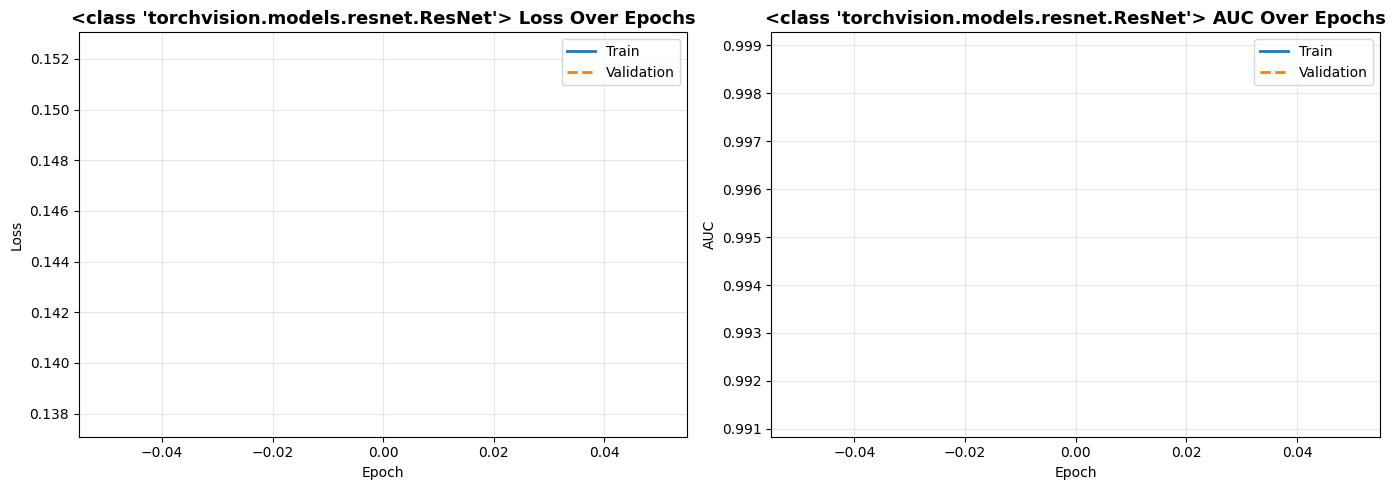

In [ ]:
name = model.__class__.__name__

Show_Curves(history,name = name)

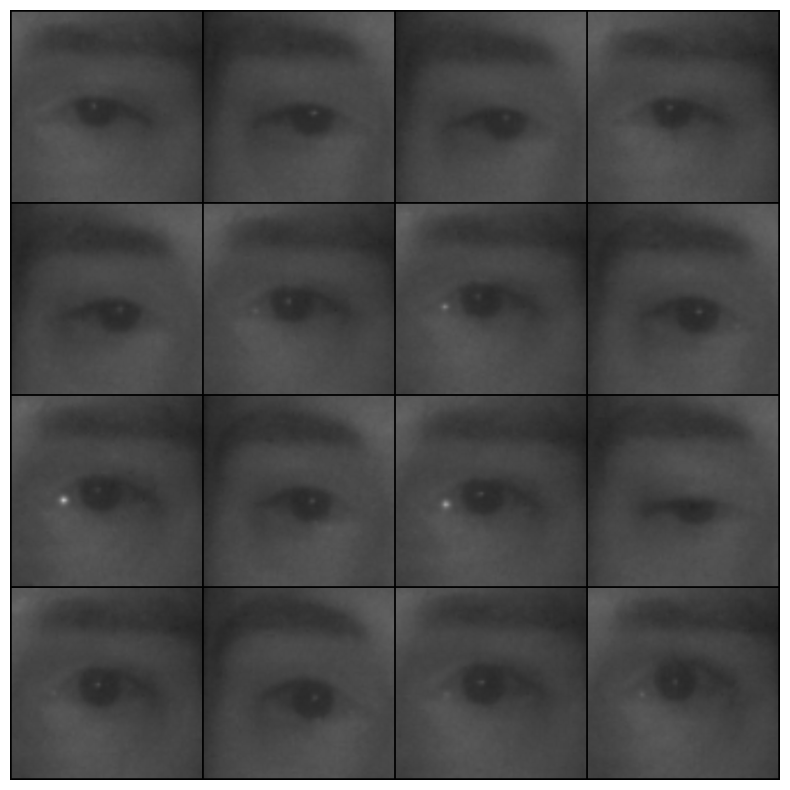

In [33]:
# Sample visualization
test_imgs, test_labels = next(iter(test_dl))

plt.figure(figsize=(10, 10))
grid = make_grid(test_imgs[:16], nrow=4).permute(1, 2, 0)

plt.imshow(grid)
plt.axis("off")
plt.show()